# About

This notebook demonstrates the two-step data processing approach used to determine the extinction cross section from measured pressure fields.

Two examples are provided:
- Scattering of a spherical wave on a sphere, where the "measured" data are generated using analytical expressions.
- Scattering of a spherical wave on a Helmholtz resonator, where the "measured" data are obtained from a COMSOL model.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import tqdm
from pathlib import Path

from mie_utils import p_n_SW, a_n_sphere, line_p_s_generator
from processing import ModelPB, ModelY, DataContainer

# Flag to control whether to skip the model optimization process and use pretrained models instead
USE_PRETRAINED_MODELS = True

# Sphere

The incident spherical wave is defined as:
$$
p_\text{b}(z, \omega) = R\frac{e^{ikz}}{z + R}
$$

The scattered field is calculated using Mie coefficients (see examples in the `1_preparation.ipynb` file).

The coordinate used in the measurements is related to the actual coordinate by:
$$
z' = z - \Delta
$$

In the code, theoretical quantities used to generate data are denoted with the `_theory` suffix.
These quantities (as well as any material parameters) are unknown during measurements.

In [2]:
a = 1  # Sphere radius
c_host = 1  # Speed of sound in the host medium
rho_host = 1  # Density of the host medium
c_sphere = 0.3  # Speed of sound inside the sphere
rho_sphere = 1  # Density of the sphere

# Theoretical parameters (used only for synthetic data generation, not for model fitting)
R_theory = 15 * a
Delta_theory = 3 * a
N_z = 1000
N_f = 1500
z_theory = np.linspace(Delta_theory, 200 * a, N_z)
k_theory = np.linspace(0.2, 1.5, N_f)

# Generate synthetic “measured” data for spherical-wave scattering on a sphere
p_b = (
    R_theory
    * np.exp(1j * k_theory[None, ...] * z_theory[..., None])
    / (z_theory[..., None] + R_theory)
)  # measured field of the shape (N_z, N_f)

N = 10
a_n = a_n_sphere(
    N=N,
    k=k_theory,
    a=a,
    c_host=c_host,
    rho_host=rho_host,
    c_sphere=c_sphere,
    rho_sphere=rho_sphere,
)  # Mie coefficients
p_n = np.array([p_n_SW(N, k_, R_theory) for k_ in k_theory]).T
p_s = np.empty((z_theory.shape[0], k_theory.shape[0]), dtype=np.complex128)

# Compute scattered field using spherical wave expansion
for i, _z in enumerate(z_theory):
    p_s[i] = sum(line_p_s_generator(kz=k_theory * _z, p_n=p_n, a_n=a_n))

The "measured" data are stored in a `DataContainer` dataclass.
Instead of angular frequency $\omega$, the frequency $\nu=\omega/(2\pi)=k\cdot c/(2\pi)$ is used, since it is more convenient to work with frequencies measured in Hz in experiments.

In [3]:
p_b_data = DataContainer(
    p=p_b,  # Measured incident pressure field
    z=z_theory - Delta_theory,  # z': coordinate where the incident field is measured
    freq=k_theory
    * c_host
    / (2 * np.pi),  # Frequency points corresponding to the incident field
)

p_s_data = DataContainer(
    p=p_s,  # # Measured scattered pressure field
    z=p_b_data.z,  # z': coordinate where the scattered field is measured
    freq=p_b_data.freq,  # Frequency points corresponding to the scattered field
)

## First Step

The model for the incident spherical wave is defined as:
$$
p_\text{b}(z', \omega) = p_0' \left(R' \frac{e^{ikz'}}{z' + R'} + \hat{r} e^{ik(L-z')}\right)
$$

For parameters that are bounded (denoted with the `_max` suffix), a sigmoid function scaled by the maximum value is used.
Thus, initial values for such parameters (`R_prime`, `L_max`) are internally transformed using the sigmoid function.

For strictly positive quantities, the softplus transformation is applied.
See the source code in `src/processing/models.py` for implementation details.

In [4]:
p_b_model = ModelPB(
    p0_prime_abs=torch.nn.Parameter(
        torch.full(p_b_data.freq.shape, 1.0),
    ),
    p0_prime_phase=torch.nn.Parameter(
        torch.full(p_b_data.freq.shape, 0.0),
    ),
    R_prime=torch.nn.Parameter(
        torch.full(p_b_data.freq.shape, 5.0),
    ),
    R_prime_max=100.0,
    c=torch.nn.Parameter(torch.tensor(0.1)),
    L=torch.nn.Parameter(torch.tensor(5.0)),
    L_max=300.0,
    r_hat_abs=torch.nn.Parameter(
        torch.full(p_b_data.freq.shape, -1.0),
    ),
    r_hat_phase=torch.nn.Parameter(
        torch.full(p_b_data.freq.shape, 0.0),
    ),
)

print(p_b_model)  # Print the initialized model parameters

ModelPB()
Parameters:
  |p0_prime|: mean=1.313, min=1.313, max=1.313
     R_prime: mean=99.331, min=99.331, max=99.331
           c: 0.744
           L: 297.992
     |r_hat|: mean=0.313, min=0.313, max=0.313


Next, the data are prepared by converting `numpy` arrays into `torch` tensors and removing points where the measured field contains NaN values.

In [5]:
freq_b_optim = torch.tensor(p_b_data.freq, dtype=torch.get_default_dtype())
_z_mask = ~np.isnan(p_b_data.p[:, 0])
p_b_optim = torch.tensor(p_b_data.p[_z_mask], dtype=torch.tensor(1 + 1j).dtype)
z_prime_b_optim = torch.tensor(p_b_data.z[_z_mask], dtype=torch.get_default_dtype())

If `USE_PRETRAINED_MODELS` is set to `False`, the data are split into batches using a dataloader, an optimizer is created, and model parameters are optimized.
If it is set to `True`, the already optimized model parameters are loaded.

In [6]:
if not USE_PRETRAINED_MODELS:
    torch.manual_seed(2001)

    dataloader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(p_b_optim, z_prime_b_optim),
        batch_size=200,
        shuffle=True,
    )

    optimizer = torch.optim.Adam(
        p_b_model.parameters(),
        lr=0.01,
    )
    losses = []

    progress_bar = tqdm.tqdm(
        range(5000),
        dynamic_ncols=True,
        leave=True,
        bar_format="{l_bar}{bar:20}{r_bar}",
    )

    for epoch in progress_bar:
        epoch_losses = []
        for batch in dataloader:
            diff = p_b_model(freq_b_optim, batch[1]) - batch[0]
            loss = torch.mean(diff.real**2 + diff.imag**2)
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

            epoch_losses.append(loss.item())

        losses.append(np.mean(epoch_losses))
        progress_bar.set_postfix({"loss": f"{losses[-1]:.3e}"})

    plt.plot(losses)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Average loss in epoch")
    plt.title("Training Loss")
    plt.show()

    # torch.save(p_b_model.state_dict(), Path.cwd() / "data" / "sphere_theory" / "models" / "p_b_model.pt")
else:
    p_b_model.load_state_dict(
        torch.load(
            Path.cwd() / "data" / "sphere_theory" / "models" / "p_b_model.pt",
            weights_only=True,
        )
    )

After optimization, we can visualize how well the model fits the data:

In [7]:
print(p_b_model)
print()
print("Exact values:")
print(f"  |p0_prime|: {R_theory/(R_theory + Delta_theory)}")
print(f"     R_prime: {R_theory + Delta_theory}")
print(f"           c: {c_host}")
print("           L: any")
print("     |r_hat|: 0")

ModelPB()
Parameters:
  |p0_prime|: mean=0.833, min=0.833, max=0.834
     R_prime: mean=18.001, min=17.989, max=18.011
           c: 1.000
           L: 297.340
     |r_hat|: mean=0.000, min=0.000, max=0.000

Exact values:
  |p0_prime|: 0.8333333333333334
     R_prime: 18
           c: 1
           L: any
     |r_hat|: 0


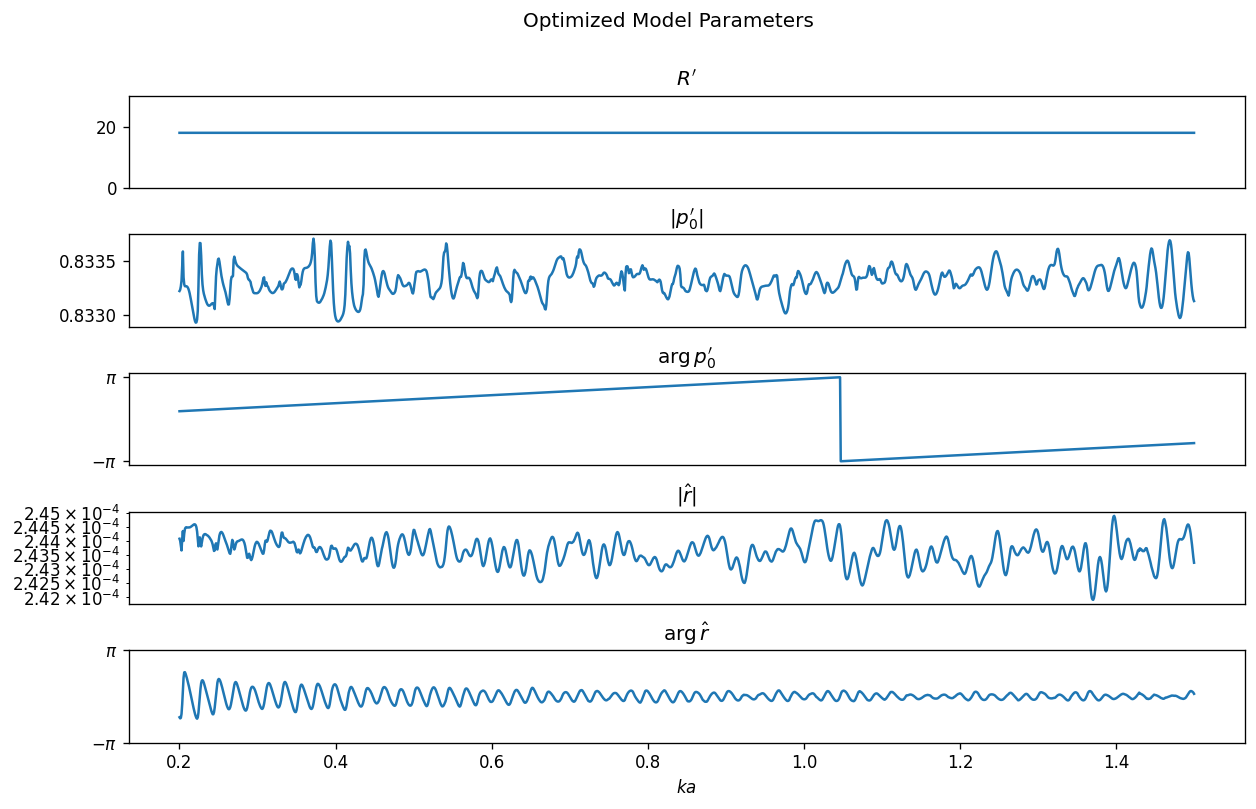

In [8]:
plt.figure(figsize=(12, 7), dpi=120)

plt.subplot(5, 1, 1)

ka = 2 * np.pi * p_b_data.freq / c_host * a
plt.plot(ka, p_b_model.R_prime.numpy(force=True))
plt.title("$R'$")
plt.xticks([])
plt.ylim(0, 30)

plt.subplot(5, 1, 2)
plt.plot(ka, np.abs(p_b_model.p0_prime.numpy(force=True)))
plt.title("$|p_0'|$")
plt.xticks([])

plt.subplot(5, 1, 3)
plt.plot(ka, np.angle(p_b_model.p0_prime.numpy(force=True)))
plt.title("$\\arg p_0'$")
plt.yticks([-np.pi, np.pi], ["$-\\pi$", "$\\pi$"])
plt.xticks([])

plt.subplot(5, 1, 4)
plt.plot(ka, np.abs(p_b_model.r_hat.numpy(force=True)))
plt.title("$|\\hat{r}|$")
plt.xticks([])
plt.yscale("log")

plt.subplot(5, 1, 5)
plt.plot(ka, np.angle(p_b_model.r_hat.numpy(force=True)))
plt.title("$\\arg \\hat{r}$")
plt.yticks([-np.pi, np.pi], ["$-\\pi$", "$\\pi$"])
plt.xlabel("$ka$")

plt.suptitle("Optimized Model Parameters")
plt.subplots_adjust(hspace=0.5)
plt.show()

Despite some oscillations, the overall behavior closely matches the theoretical values.

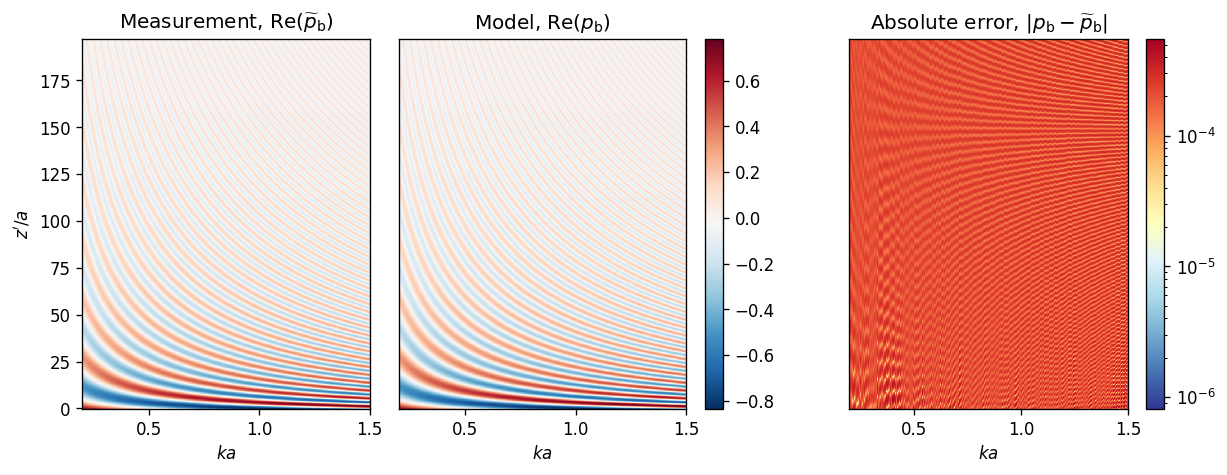

In [9]:
plt.figure(figsize=(12, 4), dpi=120)

ka = 2 * np.pi * freq_b_optim.numpy(force=True) / c_host * a
z_a = z_prime_b_optim.numpy(force=True) / a

_theory = p_b_optim.numpy(force=True)
_model = p_b_model(freq_b_optim, z_prime_b_optim).numpy(force=True)
_error = np.abs(_theory - _model)

# Determine color scale limits for consistent comparison
vmax = max(np.max(np.real(_theory)), np.max(np.real(_model)))
vmin = min(np.min(np.real(_theory)), np.min(np.real(_model)))

plt.subplot(1, 3, 1)
plt.pcolormesh(ka, z_a, np.real(_theory), vmin=vmin, vmax=vmax, cmap="RdBu_r")
plt.title("Measurement, $\\text{Re}(\\widetilde{p}_\\text{b})$")
plt.ylabel("$z'/a$")
plt.xlabel("$ka$")

plt.subplot(1, 3, 2)
cm = plt.pcolormesh(ka, z_a, np.real(_model), vmin=vmin, vmax=vmax, cmap="RdBu_r")
plt.title("Model, $\\text{Re}(p_\\text{b})$")
plt.yticks([])
plt.xlabel("$ka$")

plt.subplots_adjust(wspace=0.1)
plt.gcf().colorbar(cm, ax=plt.gcf().axes[:], pad=0.025)

plt.subplot(1, 3, 3)
plt.pcolormesh(ka, z_a, _error, cmap="RdYlBu_r", norm="log")
plt.title("Absolute error, $|p_\\text{b} - \\widetilde{p}_\\text{b}|$")
plt.yticks([])
plt.xlabel("$ka$")
plt.colorbar()

plt.show()

The residual error corresponds to the fitted $|\hat{r}|$ values.
Although the generated data contain no reflections, the model includes a reflected component.
During optimization, this reflection is not perfectly canceled, which explains the oscillating error.

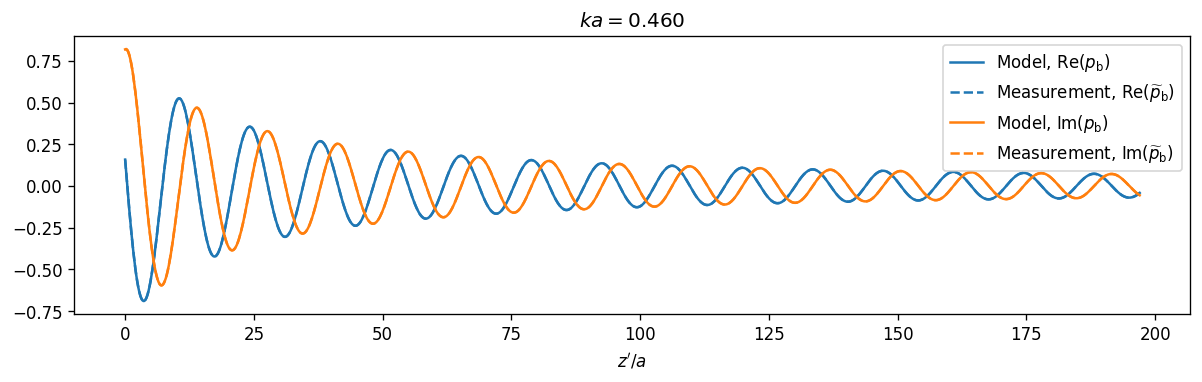

In [10]:
plt.figure(figsize=(12, 3), dpi=120)

i = 300
with torch.no_grad():
    ka = 2 * np.pi * freq_b_optim.numpy(force=True) / c_host * a
    z_a = z_prime_b_optim.numpy(force=True) / a

    _theory = p_b_optim.numpy(force=True)
    _model = p_b_model(freq_b_optim, z_prime_b_optim).numpy(force=True)

    plt.plot(z_a, np.real(_model[:, i]), label="Model, $\\text{Re}(p_\\text{b})$")
    plt.plot(
        z_a,
        np.real(_theory[:, i]),
        "--",
        color="tab:blue",
        label="Measurement, $\\text{Re}(\\widetilde{p}_\\text{b})$",
    )

    plt.plot(z_a, np.imag(_model[:, i]), label="Model, $\\text{Im}(p_\\text{b})$")
    plt.plot(
        z_a,
        np.imag(_theory[:, i]),
        "--",
        color="tab:orange",
        label="Measurement, $\\text{Im}(\\widetilde{p}_\\text{b})$",
    )

    plt.title(f"$ka = {ka[i]:.3f}$")
    plt.xlabel("$z'/a$")
    plt.legend()
    plt.show()

## Second Step

Using the parameters obtained in the first step, we compute:
$$
\widetilde{y}(z', \omega) = \text{Im}\left[\frac{\widetilde{p}_\text{s}(z', \omega)}{p_0'(\omega) e^{ikz'}}\right]
$$

In [11]:
p0_prime = p_b_model.p0_prime.numpy(force=True)[None, ...]
c = p_b_model.c.numpy(force=True)
k = 2 * np.pi * p_s_data.freq / c

y = np.imag(p_s_data.p / (p0_prime * np.exp(1j * k * p_s_data.z[..., None])))

The corresponding model for $y$ is :
$$
y(z', \omega) = \dfrac{R'}{R'-\Delta}\left[\frac{k}{4\pi}\frac{\sigma_\text{ext}}{z'+\Delta} + \frac{\text{Im} A}{(k[z'+\Delta])^2} + \bar{C}\right]
$$

In [12]:
y_model = ModelY(
    R_prime=p_b_model.R_prime.detach(),
    c=p_b_model.c.detach(),
    Delta=torch.nn.Parameter(torch.tensor(-5.0)),
    Delta_max=10.0,
    sigma=torch.nn.Parameter(
        torch.full(p_s_data.freq.shape, 2.0),
    ),
    A_im=torch.nn.Parameter(
        torch.full(p_s_data.freq.shape, 0.0),
    ),
    C=torch.nn.Parameter(
        torch.full(p_s_data.freq.shape, 0.0),
    ),
)

print(y_model)  # Print the initialized model parameters

ModelY()
Parameters:
  Delta: 0.067
  sigma: mean=2.127, min=2.127, max=2.127
   A_im: mean=0.000, min=0.000, max=0.000
      C: mean=0.000, min=0.000, max=0.000


The optimization procedure follows the same pipeline as in the first step.

In [13]:
freq_y_optim = torch.tensor(p_s_data.freq, dtype=torch.get_default_dtype())
_z_mask = ~np.isnan(y[:, 0])
y_optim = torch.tensor(y[_z_mask], dtype=torch.get_default_dtype())
z_prime_y_optim = torch.tensor(p_s_data.z[_z_mask], dtype=torch.get_default_dtype())

In [14]:
if not USE_PRETRAINED_MODELS:
    torch.manual_seed(2007)

    dataloader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(y_optim, z_prime_y_optim),
        batch_size=200,
        shuffle=True,
    )

    optimizer = torch.optim.Adam(
        y_model.parameters(),
        lr=5e-3,
    )
    losses = []

    progress_bar = tqdm.tqdm(
        range(8000),
        dynamic_ncols=True,
        leave=True,
        bar_format="{l_bar}{bar:20}{r_bar}",
    )

    for epoch in progress_bar:

        epoch_losses = []
        for batch in dataloader:

            loss = torch.mean(
                torch.abs(y_model(freq_y_optim, batch[1]) - batch[0]) ** 2
            )
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

            epoch_losses.append(loss.item())

        losses.append(np.mean(epoch_losses))
        progress_bar.set_postfix({"loss": f"{losses[-1]:.3e}"})

    plt.plot(losses)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Average loss in epoch")
    plt.title("Training Loss")
    plt.show()

    # torch.save(y_model.state_dict(), Path.cwd() / "data" / "sphere_theory" / "models" / "y_model.pt")
else:
    y_model.load_state_dict(
        torch.load(
            Path.cwd() / "data" / "sphere_theory" / "models" / "y_model.pt",
            weights_only=True,
        )
    )

In [15]:
print(y_model)  # Print the optimized model parameters

ModelY()
Parameters:
  Delta: 2.813
  sigma: mean=19.997, min=0.812, max=57.533
   A_im: mean=-0.968, min=-11.672, max=2.295
      C: mean=0.000, min=-0.001, max=0.000


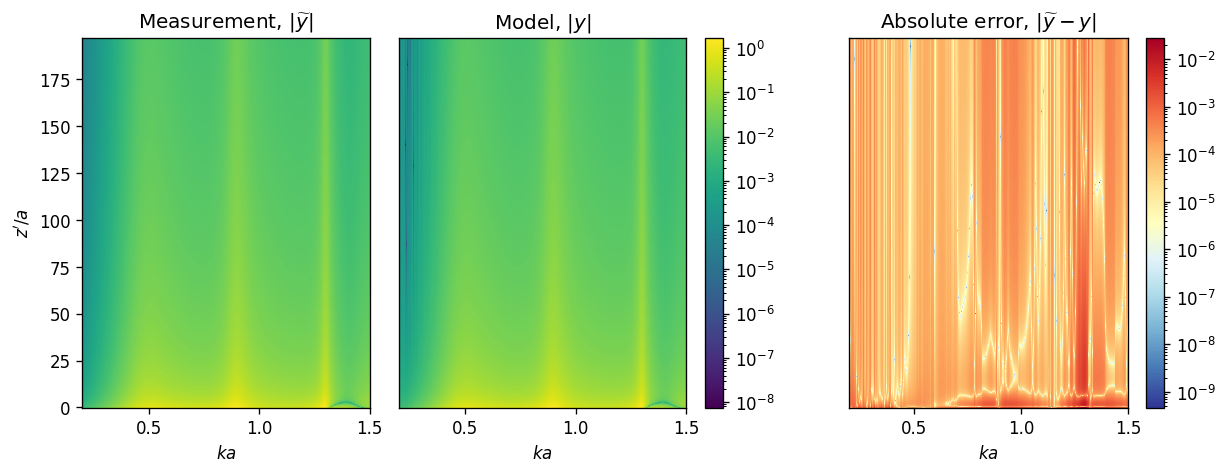

In [16]:
plt.figure(figsize=(12, 4), dpi=120)

ka = 2 * np.pi * freq_y_optim.numpy(force=True) / c_host * a
z_a = z_prime_y_optim.numpy(force=True) / a

_theory = y_optim.numpy(force=True)
_model = y_model(freq_y_optim, z_prime_y_optim).numpy(force=True)
_error = np.abs(_theory - _model)

vmax = max(np.max(np.abs(_theory)), np.max(np.abs(_model)))
vmin = min(np.min(np.abs(_theory)), np.min(np.abs(_model)))

plt.subplot(1, 3, 1)
plt.pcolormesh(
    ka, z_a, np.abs(_theory), vmin=vmin, vmax=vmax, cmap="viridis", norm="log"
)
plt.title("Measurement, $|\\widetilde{y}|$")
plt.ylabel("$z'/a$")
plt.xlabel("$ka$")

plt.subplot(1, 3, 2)
cm = plt.pcolormesh(
    ka, z_a, np.abs(_model), vmin=vmin, vmax=vmax, cmap="viridis", norm="log"
)
plt.title("Model, $|y|$")
plt.yticks([])
plt.xlabel("$ka$")

plt.subplots_adjust(wspace=0.1)
plt.gcf().colorbar(cm, ax=plt.gcf().axes[:], pad=0.025)

plt.subplot(1, 3, 3)
plt.pcolormesh(ka, z_a, _error, cmap="RdYlBu_r", norm="log")
plt.title("Absolute error, $|\\widetilde{y} - y|$")
plt.yticks([])
plt.xlabel("$ka$")
plt.colorbar()

plt.show()

Now we compare the obtained extinction cross-section with the exact solution and the value computed directly using the optical theorem.

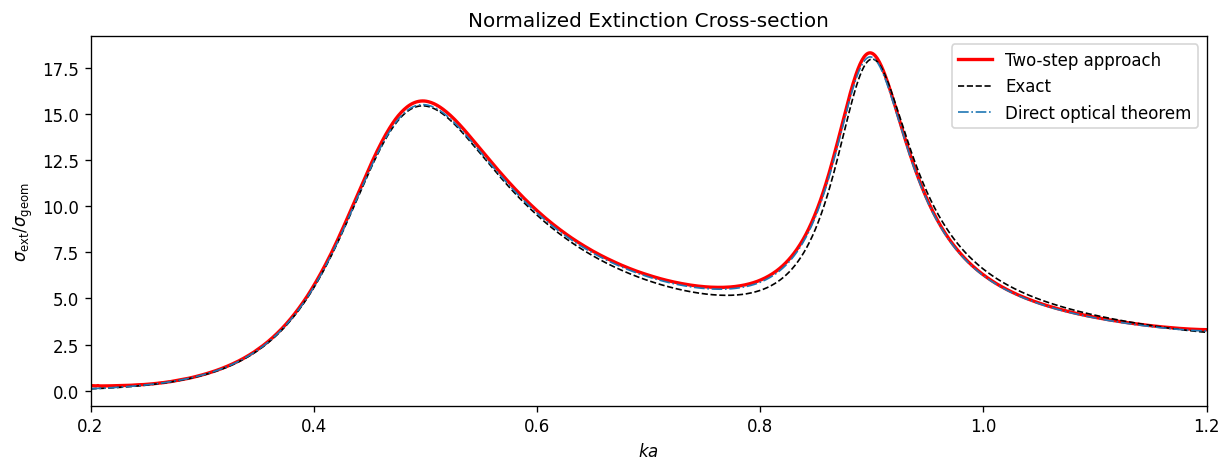

In [17]:
plt.figure(figsize=(12, 4), dpi=120)

ka = 2 * np.pi * freq_y_optim.numpy(force=True) / c_host * a
sigma_geom = np.pi * a**2

# Plot extinction cross-section obtained from optimization
plt.plot(
    ka,
    y_model.sigma.numpy(force=True) / sigma_geom,
    label="Two-step approach",
    color="red",
    linewidth=2,
)


# Calculate the exact extinction cross-section for an incident plane wave
a_n = a_n_sphere(N, ka / a, a, c_host, rho_host, c_sphere, rho_sphere)
sigma_ext_exact = (
    -4 * np.pi / (ka / a) ** 2 * np.real((2 * np.arange(N + 1) + 1.0) @ a_n)
)
plt.plot(
    ka, sigma_ext_exact / sigma_geom, "--", label="Exact", color="black", linewidth=1
)


# Calculate the extinction cross-section directly using the optical theorem
sigma_ext = (
    4
    * np.pi
    / (ka / a)
    * np.imag(p_s_data.p[-1] / p_b_data.p[-1])
    * z_theory[-1]
    * R_theory
    / (R_theory + z_theory[-1])
)
plt.plot(ka, sigma_ext / sigma_geom, "-.", label="Direct optical theorem", linewidth=1)


plt.xlim(0.2, 1.2)
plt.legend()
plt.xlabel("$ka$")
plt.ylabel("$\\sigma_\\text{ext} / \\sigma_\\text{geom}$")
plt.title("Normalized Extinction Cross-section")
plt.show()

The resulting extinction cross-section agrees well with the values obtained using the optical theorem directly.
To further reduce the discrepancy between the two approaches and the exact extinction cross-section (for the case of a plane wave), the distance between the point source and the sphere center $R$ should be increased.

# Helmholtz resonator

First, we load the data calculated using COMSOL.
These data are located in the `data/helmholtz_sw_comsol` directory, along with `script.py`, which was used to generate them.

In [19]:
_data_p_b = np.load(Path.cwd() / "data" / "helmholtz_sw_comsol" / "p_b.npz")

p_b_data = DataContainer(
    p=_data_p_b["p"],
    z=_data_p_b["z"],
    freq=_data_p_b["freq"],
)

_data_p_s = np.load(Path.cwd() / "data" / "helmholtz_sw_comsol" / "p_s.npz")

p_s_data = DataContainer(
    p=_data_p_s["p"],
    z=_data_p_s["z"],
    freq=_data_p_s["freq"],
)

assert np.allclose(p_b_data.z, p_s_data.z)

## First Step

This step is the same as for the sphere above, so the code remains unchanged.

In [20]:
p_b_model = ModelPB(
    p0_prime_abs=torch.nn.Parameter(
        torch.full(p_b_data.freq.shape, 1.0),
    ),
    p0_prime_phase=torch.nn.Parameter(
        torch.full(p_b_data.freq.shape, 0.0),
    ),
    R_prime=torch.nn.Parameter(
        torch.full(p_b_data.freq.shape, 1.0),
    ),
    R_prime_max=1.0,
    c=torch.nn.Parameter(torch.tensor(300.0)),
    L=torch.nn.Parameter(torch.tensor(20.0)),
    L_max=30.0,
    r_hat_abs=torch.nn.Parameter(
        torch.full(p_b_data.freq.shape, -2.0),
    ),
    r_hat_phase=torch.nn.Parameter(
        torch.full(p_b_data.freq.shape, 0.0),
    ),
)

print(p_b_model)  # Print the initialized model parameters

ModelPB()
Parameters:
  |p0_prime|: mean=1.313, min=1.313, max=1.313
     R_prime: mean=0.731, min=0.731, max=0.731
           c: 300.000
           L: 30.000
     |r_hat|: mean=0.127, min=0.127, max=0.127


In [21]:
freq_b_optim = torch.tensor(p_b_data.freq, dtype=torch.get_default_dtype())
_z_mask = ~np.isnan(p_b_data.p[:, 0])
p_b_optim = torch.tensor(p_b_data.p[_z_mask], dtype=torch.tensor(1 + 1j).dtype)
z_prime_b_optim = torch.tensor(p_b_data.z[_z_mask], dtype=torch.get_default_dtype())

In [22]:
if not USE_PRETRAINED_MODELS:
    torch.manual_seed(2001)

    dataloader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(p_b_optim, z_prime_b_optim),
        batch_size=100,
        shuffle=True,
    )

    optimizer = torch.optim.Adam(
        p_b_model.parameters(),
        lr=0.01,
    )
    losses = []

    progress_bar = tqdm.tqdm(
        range(5000),
        dynamic_ncols=True,
        leave=True,
        bar_format="{l_bar}{bar:20}{r_bar}",
    )

    for epoch in progress_bar:
        epoch_losses = []
        for batch in dataloader:
            diff = p_b_model(freq_b_optim, batch[1]) - batch[0]
            loss = torch.mean(diff.real**2 + diff.imag**2)
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

            epoch_losses.append(loss.item())

        losses.append(np.mean(epoch_losses))
        progress_bar.set_postfix({"loss": f"{losses[-1]:.3e}"})

    plt.plot(losses)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Average loss in epoch")
    plt.title("Training Loss")
    plt.show()

    # torch.save(p_b_model.state_dict(), Path.cwd() / "data" / "helmholtz_sw_comsol" / "models" / "p_b_model.pt")
else:
    p_b_model.load_state_dict(
        torch.load(
            Path.cwd() / "data" / "helmholtz_sw_comsol" / "models" / "p_b_model.pt",
            weights_only=True,
        )
    )

In [23]:
print(p_b_model)

ModelPB()
Parameters:
  |p0_prime|: mean=1.000, min=1.000, max=1.000
     R_prime: mean=0.700, min=0.700, max=0.700
           c: 343.200
           L: 30.000
     |r_hat|: mean=0.000, min=0.000, max=0.000


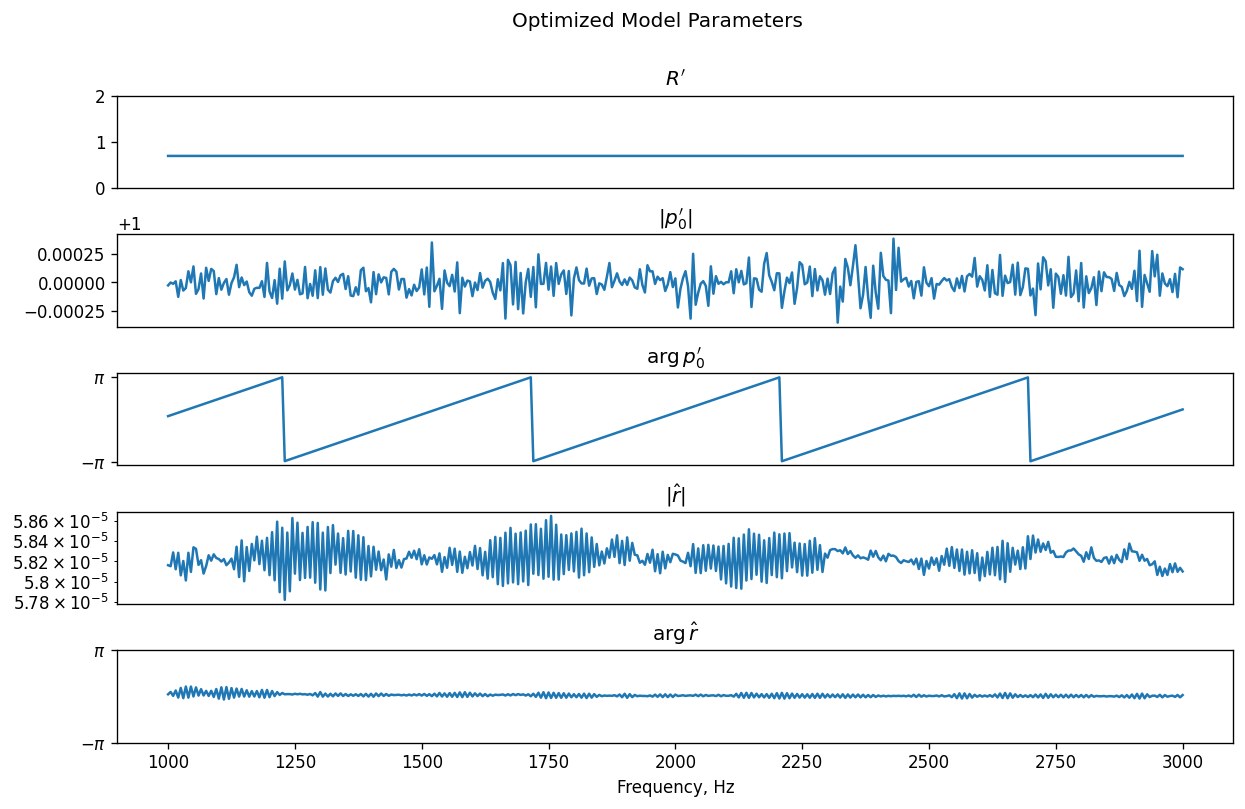

In [24]:
plt.figure(figsize=(12, 7), dpi=120)

plt.subplot(5, 1, 1)

plt.plot(p_b_data.freq, p_b_model.R_prime.numpy(force=True))
plt.title("$R'$")
plt.xticks([])
plt.ylim(0, 2)

plt.subplot(5, 1, 2)
plt.plot(p_b_data.freq, np.abs(p_b_model.p0_prime.numpy(force=True)))
plt.title("$|p_0'|$")
plt.xticks([])

plt.subplot(5, 1, 3)
plt.plot(p_b_data.freq, np.angle(p_b_model.p0_prime.numpy(force=True)))
plt.title("$\\arg p_0'$")
plt.yticks([-np.pi, np.pi], ["$-\\pi$", "$\\pi$"])
plt.xticks([])

plt.subplot(5, 1, 4)
plt.plot(p_b_data.freq, np.abs(p_b_model.r_hat.numpy(force=True)))
plt.title("$|\\hat{r}|$")
plt.xticks([])
plt.yscale("log")

plt.subplot(5, 1, 5)
plt.plot(p_b_data.freq, np.angle(p_b_model.r_hat.numpy(force=True)))
plt.title("$\\arg \\hat{r}$")
plt.yticks([-np.pi, np.pi], ["$-\\pi$", "$\\pi$"])
plt.xlabel("Frequency, Hz")

plt.suptitle("Optimized Model Parameters")
plt.subplots_adjust(hspace=0.5)
plt.show()

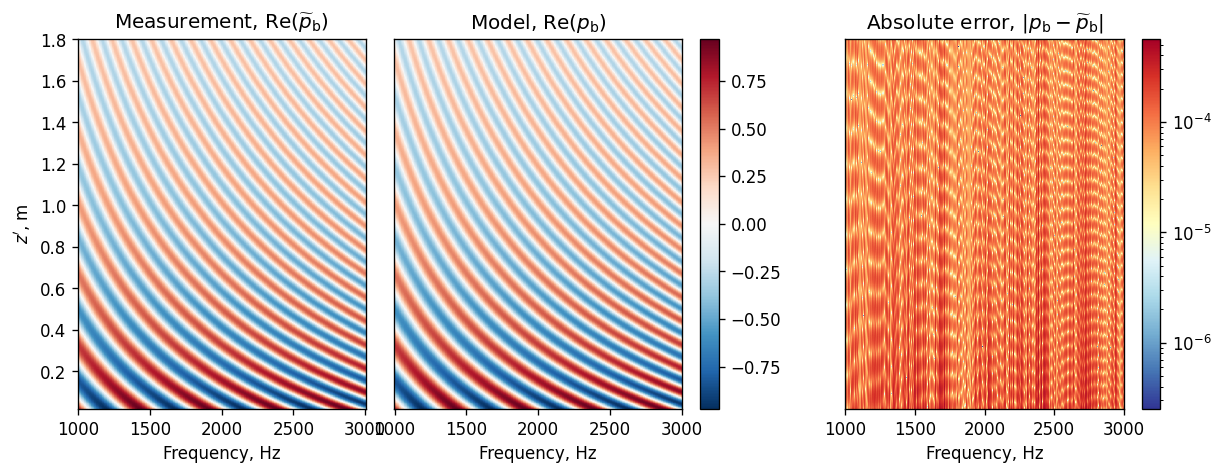

In [25]:
plt.figure(figsize=(12, 4), dpi=120)

z = z_prime_b_optim.numpy(force=True)

_theory = p_b_optim.numpy(force=True)
_model = p_b_model(freq_b_optim, z_prime_b_optim).numpy(force=True)
_error = np.abs(_theory - _model)

# Determine color scale limits for consistent comparison
vmax = max(np.max(np.real(_theory)), np.max(np.real(_model)))
vmin = min(np.min(np.real(_theory)), np.min(np.real(_model)))

plt.subplot(1, 3, 1)
plt.pcolormesh(freq_b_optim, z, np.real(_theory), vmin=vmin, vmax=vmax, cmap="RdBu_r")
plt.title("Measurement, $\\text{Re}(\\widetilde{p}_\\text{b})$")
plt.ylabel("$z'$, m")
plt.xlabel("Frequency, Hz")

plt.subplot(1, 3, 2)
cm = plt.pcolormesh(
    freq_b_optim, z, np.real(_model), vmin=vmin, vmax=vmax, cmap="RdBu_r"
)
plt.title("Model, $\\text{Re}(p_\\text{b})$")
plt.yticks([])
plt.xlabel("Frequency, Hz")

plt.subplots_adjust(wspace=0.1)
plt.gcf().colorbar(cm, ax=plt.gcf().axes[:], pad=0.025)

plt.subplot(1, 3, 3)
plt.pcolormesh(freq_b_optim, z, _error, cmap="RdYlBu_r", norm="log")
plt.title("Absolute error, $|p_\\text{b} - \\widetilde{p}_\\text{b}|$")
plt.yticks([])
plt.xlabel("Frequency, Hz")
plt.colorbar()

plt.show()

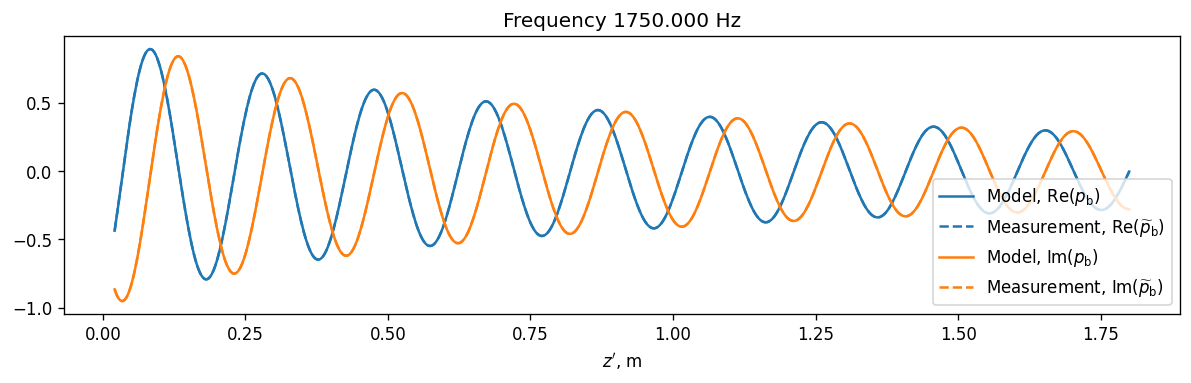

In [26]:
plt.figure(figsize=(12, 3), dpi=120)

i = 150
with torch.no_grad():
    z = z_prime_b_optim.numpy(force=True)

    _theory = p_b_optim.numpy(force=True)
    _model = p_b_model(freq_b_optim, z_prime_b_optim).numpy(force=True)

    plt.plot(z, np.real(_model[:, i]), label="Model, $\\text{Re}(p_\\text{b})$")
    plt.plot(
        z,
        np.real(_theory[:, i]),
        "--",
        color="tab:blue",
        label="Measurement, $\\text{Re}(\\widetilde{p}_\\text{b})$",
    )

    plt.plot(z, np.imag(_model[:, i]), label="Model, $\\text{Im}(p_\\text{b})$")
    plt.plot(
        z,
        np.imag(_theory[:, i]),
        "--",
        color="tab:orange",
        label="Measurement, $\\text{Im}(\\widetilde{p}_\\text{b})$",
    )

    plt.title(f"Frequency {freq_b_optim.numpy(force=True)[i]:.3f} Hz")
    plt.xlabel("$z'$, m")
    plt.legend()
    plt.show()

## Second Step

In [27]:
p0_prime = p_b_model.p0_prime.numpy(force=True)[None, ...]
c = p_b_model.c.numpy(force=True)
k = 2 * np.pi * p_s_data.freq / c

y = np.imag(p_s_data.p / (p0_prime * np.exp(1j * k * p_s_data.z[..., None])))

In [28]:
y_model = ModelY(
    R_prime=p_b_model.R_prime.detach(),
    c=p_b_model.c.detach(),
    Delta=torch.nn.Parameter(torch.tensor(-5.0)),
    Delta_max=0.01,
    sigma=torch.nn.Parameter(
        torch.full(p_s_data.freq.shape, 1.0),
    ),
    A_im=torch.nn.Parameter(
        torch.full(p_s_data.freq.shape, 0.0),
    ),
    C=torch.nn.Parameter(
        torch.full(p_s_data.freq.shape, 0.0),
    ),
)

print(y_model)  # Print the initialized model parameters

ModelY()
Parameters:
  Delta: 0.000
  sigma: mean=1.313, min=1.313, max=1.313
   A_im: mean=0.000, min=0.000, max=0.000
      C: mean=0.000, min=0.000, max=0.000


In [29]:
freq_y_optim = torch.tensor(p_s_data.freq, dtype=torch.get_default_dtype())
_z_mask = ~np.isnan(y[:, 0])
y_optim = torch.tensor(y[_z_mask], dtype=torch.get_default_dtype())
z_prime_y_optim = torch.tensor(p_s_data.z[_z_mask], dtype=torch.get_default_dtype())

In [30]:
if not USE_PRETRAINED_MODELS:
    torch.manual_seed(2007)

    dataloader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(y_optim, z_prime_y_optim),
        batch_size=100,
        shuffle=True,
    )

    optimizer = torch.optim.Adam(
        y_model.parameters(),
        lr=0.01,
    )
    losses = []

    progress_bar = tqdm.tqdm(
        range(8000),
        dynamic_ncols=True,
        leave=True,
        bar_format="{l_bar}{bar:20}{r_bar}",
    )

    for epoch in progress_bar:

        epoch_losses = []
        for batch in dataloader:

            loss = torch.mean(
                torch.abs(y_model(freq_y_optim, batch[1]) - batch[0]) ** 2
            )
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

            epoch_losses.append(loss.item())

        losses.append(np.mean(epoch_losses))
        progress_bar.set_postfix({"loss": f"{losses[-1]:.3e}"})

    plt.plot(losses)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Average loss in epoch")
    plt.title("Training Loss")
    plt.show()

    # torch.save(y_model.state_dict(), Path.cwd() / "data" / "helmholtz_sw_comsol" / "models" / "y_model.pt")
else:
    y_model.load_state_dict(
        torch.load(
            Path.cwd() / "data" / "helmholtz_sw_comsol" / "models" / "y_model.pt",
            weights_only=True,
        )
    )

In [31]:
print(y_model)  # Print the optimized model parameters

ModelY()
Parameters:
  Delta: 0.010
  sigma: mean=0.000, min=0.000, max=0.004
   A_im: mean=0.066, min=-0.093, max=0.207
      C: mean=0.000, min=-0.000, max=0.001


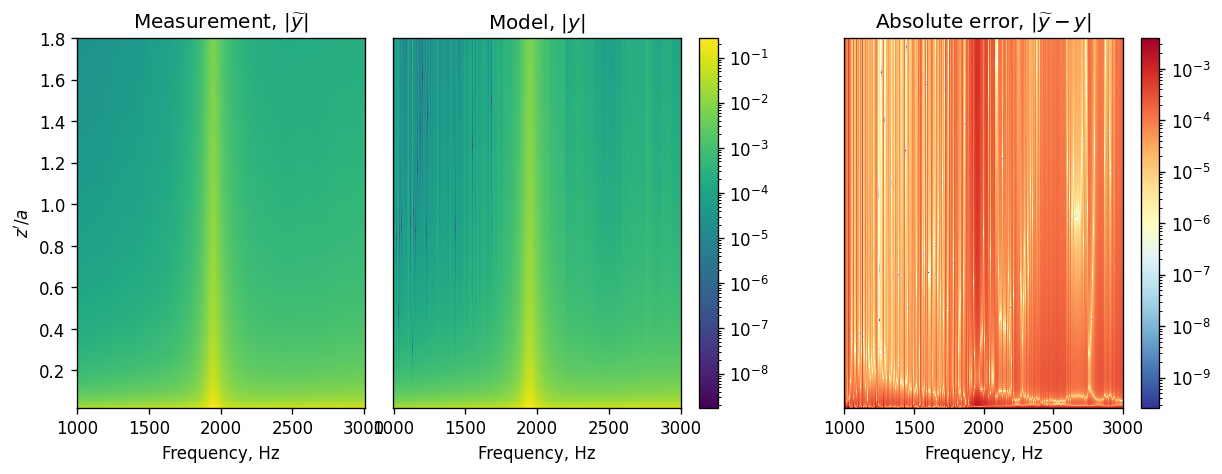

In [32]:
plt.figure(figsize=(12, 4), dpi=120)

z = z_prime_y_optim.numpy(force=True)

_theory = y_optim.numpy(force=True)
_model = y_model(freq_y_optim, z_prime_y_optim).numpy(force=True)
_error = np.abs(_theory - _model)

vmax = max(np.max(np.abs(_theory)), np.max(np.abs(_model)))
vmin = min(np.min(np.abs(_theory)), np.min(np.abs(_model)))

plt.subplot(1, 3, 1)
plt.pcolormesh(
    freq_y_optim.numpy(force=True),
    z,
    np.abs(_theory),
    vmin=vmin,
    vmax=vmax,
    cmap="viridis",
    norm="log",
)
plt.title("Measurement, $|\\widetilde{y}|$")
plt.ylabel("$z'/a$")
plt.xlabel("Frequency, Hz")

plt.subplot(1, 3, 2)
cm = plt.pcolormesh(
    freq_y_optim.numpy(force=True),
    z,
    np.abs(_model),
    vmin=vmin,
    vmax=vmax,
    cmap="viridis",
    norm="log",
)
plt.title("Model, $|y|$")
plt.yticks([])
plt.xlabel("Frequency, Hz")

plt.subplots_adjust(wspace=0.1)
plt.gcf().colorbar(cm, ax=plt.gcf().axes[:], pad=0.025)

plt.subplot(1, 3, 3)
plt.pcolormesh(freq_y_optim.numpy(force=True), z, _error, cmap="RdYlBu_r", norm="log")
plt.title("Absolute error, $|\\widetilde{y} - y|$")
plt.yticks([])
plt.xlabel("Frequency, Hz")
plt.colorbar()

plt.show()

Now we compare the extinction cross-section we obtained with the one precomputed in COMSOL using an integral formulation for a plane wave.
The scripts and data for this calculation are located in `data/helmholtz_pw_comsol`.

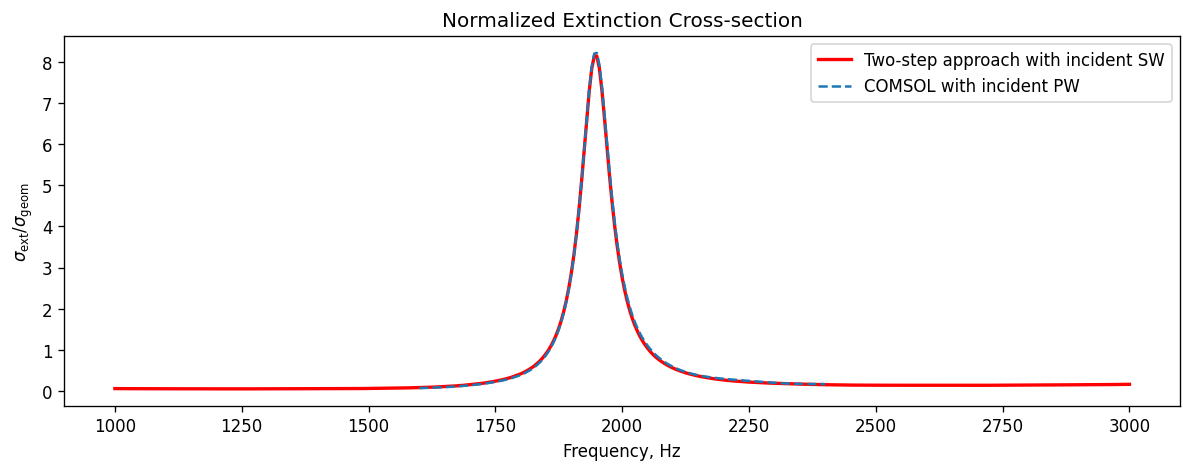

In [35]:
plt.figure(figsize=(12, 4), dpi=120)

sigma_geom = np.pi * (0.0239 / 2) ** 2


# Plot extinction cross-section obtained from optimization
plt.plot(
    freq_y_optim.numpy(force=True),
    y_model.sigma.numpy(force=True) / sigma_geom,
    label="Two-step approach with incident SW",
    color="red",
    linewidth=2,
)

# Load COMSOL results for plane-wave excitation
df = pd.read_csv(Path.cwd() / "data" / "helmholtz_pw_comsol" / "sigma.csv")

# Select only the configuration with d_wall_p = 2.1,
# which corresponds to the geometry used in the two-step approach
df_pw = df[df["d_wall_p"] == 2.1]
plt.plot(
    df_pw["freq"],
    df_pw["sigma_ext"] / sigma_geom,
    "--",
    label="COMSOL with incident PW",
)

plt.legend()
plt.xlabel("Frequency, Hz")
plt.ylabel("$\\sigma_\\text{ext} / \\sigma_\\text{geom}$")
plt.title("Normalized Extinction Cross-section")
plt.show()